<a href="https://colab.research.google.com/github/Adityadeeenair/F1-time-series-analysis/blob/main/F1_Lap_Time_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastf1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.2 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.2-cp312-cp312-linux_x86_64.whl size=15820 sha256=3a1fa3c63e062b1eadb1e5fb652244807795170e133b914ce2607cf8e535d1cf
  Stored in directory: /root/.cache/pip/wheels/67/a6/40/eda0983e595bbf3841af96dbff2340be72dfac96796fc3d578
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.2
    Uninstalling msgpack-1.1.2:
      Successfully uninstalled msgpack-1.1.2
  Attempting uninstall: websocket

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import fastf1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
import os
os.makedirs('/content/f1_cache', exist_ok=True)

In [ ]:
fastf1.Cache.enable_cache('/content/f1_cache')
print("FastF1 cache enabled ✅")

FastF1 cache enabled ✅


In [ ]:
session = fastf1.get_session(2023, 'Bahrain', 'R')
session.load()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

In [ ]:
laps = session.laps
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,False,Red Bull Racing,0 days 01:02:36.652000,2023-03-05 15:03:38.501,12,1.0,False,,False,False
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,False,Red Bull Racing,0 days 01:04:15.902000,2023-03-05 15:05:17.751,12,1.0,False,,False,True
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,False,Red Bull Racing,0 days 01:05:53.876000,2023-03-05 15:06:55.725,1,1.0,False,,False,True
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,False,Red Bull Racing,0 days 01:07:31.882000,2023-03-05 15:08:33.731,1,1.0,False,,False,True
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,False,Red Bull Racing,0 days 01:09:09.858000,2023-03-05 15:10:11.707,1,1.0,False,,False,True


In [ ]:
ver_laps = laps[laps['Driver'] == 'VER']
ver_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,False,Red Bull Racing,0 days 01:02:36.652000,2023-03-05 15:03:38.501,12,1.0,False,,False,False
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,False,Red Bull Racing,0 days 01:04:15.902000,2023-03-05 15:05:17.751,12,1.0,False,,False,True
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,False,Red Bull Racing,0 days 01:05:53.876000,2023-03-05 15:06:55.725,1,1.0,False,,False,True
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,False,Red Bull Racing,0 days 01:07:31.882000,2023-03-05 15:08:33.731,1,1.0,False,,False,True
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,False,Red Bull Racing,0 days 01:09:09.858000,2023-03-05 15:10:11.707,1,1.0,False,,False,True


In [ ]:
ham_laps = laps[laps['Driver'] == 'HAM'].copy()
ham_laps.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
815,0 days 01:04:19.171000,HAM,44,0 days 00:01:42.288000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:43.494000,...,False,Mercedes,0 days 01:02:36.652000,2023-03-05 15:03:38.501,12,5.0,False,,False,False
816,0 days 01:05:58.337000,HAM,44,0 days 00:01:39.166000,2.0,1.0,NaT,NaT,0 days 00:00:31.408000,0 days 00:00:43.352000,...,False,Mercedes,0 days 01:04:19.171000,2023-03-05 15:05:21.020,21,5.0,False,,False,True
817,0 days 01:07:37.557000,HAM,44,0 days 00:01:39.220000,3.0,1.0,NaT,NaT,0 days 00:00:31.298000,0 days 00:00:43.499000,...,False,Mercedes,0 days 01:05:58.337000,2023-03-05 15:07:00.186,1,5.0,False,,False,True
818,0 days 01:09:16.755000,HAM,44,0 days 00:01:39.198000,4.0,1.0,NaT,NaT,0 days 00:00:31.315000,0 days 00:00:43.446000,...,False,Mercedes,0 days 01:07:37.557000,2023-03-05 15:08:39.406,1,5.0,False,,False,True
819,0 days 01:10:56.090000,HAM,44,0 days 00:01:39.335000,5.0,1.0,NaT,NaT,0 days 00:00:31.350000,0 days 00:00:43.508000,...,False,Mercedes,0 days 01:09:16.755000,2023-03-05 15:10:18.604,1,5.0,False,,False,True


In [ ]:
ver_laps = ver_laps[['LapNumber', 'LapTime']]
ver_laps.head()

,LapNumber,LapTime
0,1.0,0 days 00:01:39.019000
1,2.0,0 days 00:01:37.974000
2,3.0,0 days 00:01:38.006000
3,4.0,0 days 00:01:37.976000
4,5.0,0 days 00:01:38.035000


In [ ]:
ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()
ver_laps.head()

,LapNumber,LapTime,LapTimeSeconds
0,1.0,0 days 00:01:39.019000,99.019
1,2.0,0 days 00:01:37.974000,97.974
2,3.0,0 days 00:01:38.006000,98.006
3,4.0,0 days 00:01:37.976000,97.976
4,5.0,0 days 00:01:38.035000,98.035


In [ ]:
ham_laps['LapTimeSeconds'] = ham_laps['LapTime'].dt.total_seconds()
ham_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
815,0 days 01:04:19.171000,HAM,44,0 days 00:01:42.288000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:43.494000,...,Mercedes,0 days 01:02:36.652000,2023-03-05 15:03:38.501,12,5.0,False,,False,False,102.288
816,0 days 01:05:58.337000,HAM,44,0 days 00:01:39.166000,2.0,1.0,NaT,NaT,0 days 00:00:31.408000,0 days 00:00:43.352000,...,Mercedes,0 days 01:04:19.171000,2023-03-05 15:05:21.020,21,5.0,False,,False,True,99.166
817,0 days 01:07:37.557000,HAM,44,0 days 00:01:39.220000,3.0,1.0,NaT,NaT,0 days 00:00:31.298000,0 days 00:00:43.499000,...,Mercedes,0 days 01:05:58.337000,2023-03-05 15:07:00.186,1,5.0,False,,False,True,99.220
818,0 days 01:09:16.755000,HAM,44,0 days 00:01:39.198000,4.0,1.0,NaT,NaT,0 days 00:00:31.315000,0 days 00:00:43.446000,...,Mercedes,0 days 01:07:37.557000,2023-03-05 15:08:39.406,1,5.0,False,,False,True,99.198
819,0 days 01:10:56.090000,HAM,44,0 days 00:01:39.335000,5.0,1.0,NaT,NaT,0 days 00:00:31.350000,0 days 00:00:43.508000,...,Mercedes,0 days 01:09:16.755000,2023-03-05 15:10:18.604,1,5.0,False,,False,True,99.335


**GRAPH DEMONSTRATION :**

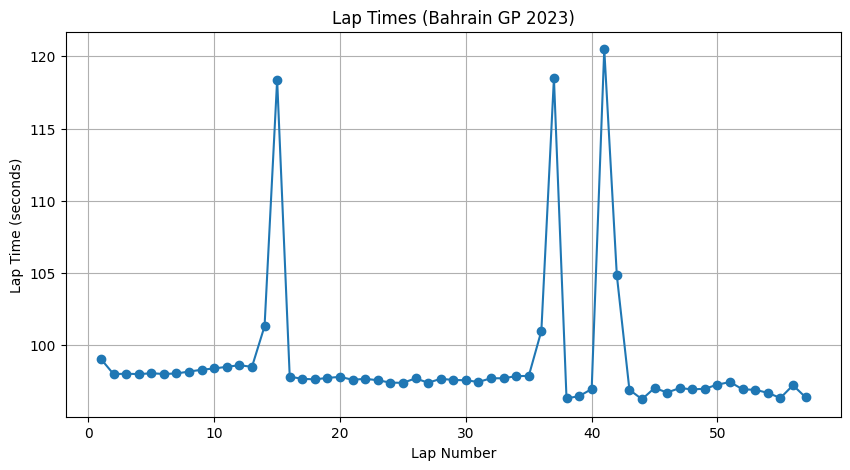

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ver_laps['LapNumber'], ver_laps['LapTimeSeconds'], marker='o')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Lap Times (Bahrain GP 2023)')
plt.grid(True)
plt.show()


In [ ]:
# Remove laps where lap time is unusually high (pit laps) bcoz or else prediction will be false prediction
clean_laps = ver_laps[ver_laps['LapTimeSeconds'] < 105].copy()

clean_laps.head()


,LapNumber,LapTime,LapTimeSeconds
0,1.0,0 days 00:01:39.019000,99.019
1,2.0,0 days 00:01:37.974000,97.974
2,3.0,0 days 00:01:38.006000,98.006
3,4.0,0 days 00:01:37.976000,97.976
4,5.0,0 days 00:01:38.035000,98.035


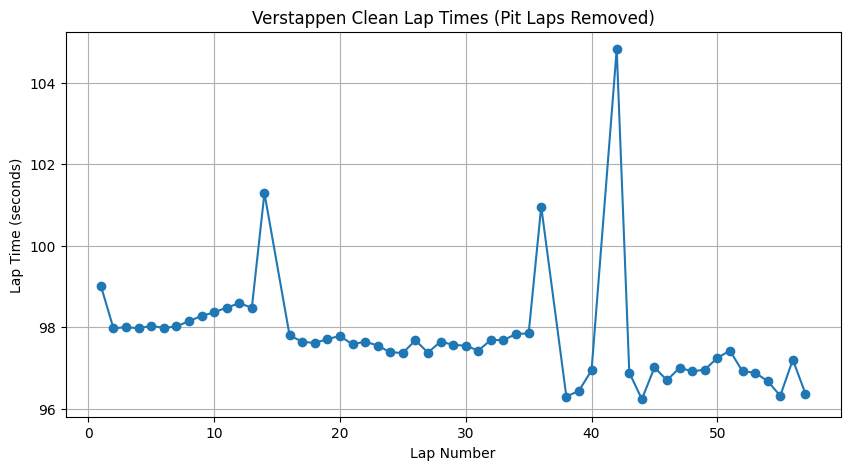

In [ ]:
#Replotting after removing laptime :

plt.figure(figsize=(10, 5))
plt.plot(clean_laps['LapNumber'], clean_laps['LapTimeSeconds'], marker='o')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Verstappen Clean Lap Times (Pit Laps Removed)')
plt.grid(True)
plt.show()


# **Scale the data**

In [ ]:
scaler = MinMaxScaler()
lap_times = clean_laps['LapTimeSeconds'].values

lap_times_scaled = scaler.fit_transform(lap_times.reshape(-1, 1))
lap_times_scaled[:10]


array([[0.32405682],
       [0.20237541],
       [0.20610154],
       [0.20260829],
       [0.20947834],
       [0.20377271],
       [0.20784816],
       [0.22333489],
       [0.23777364],
       [0.24836982]])

In [ ]:
def create_sequences(data, window_size=5):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)


In [ ]:
window_size = 5

X, y = create_sequences(
    lap_times_scaled.flatten(),
    window_size
)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (49, 5)
y shape: (49,)


# **Reshape X for LSTM**

In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))
X.shape

(49, 5, 1)

# **TRAINING LSTM MODEL**

In [ ]:
model = Sequential([LSTM(64, input_shape=(X.shape[1], 1)), Dense(1)])

model.compile(optimizer='adam',loss='mse')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit( X, y, epochs=30, batch_size=8, verbose=1 )

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0485
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0441 
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0307 
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0170 
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0192 
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0308 
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0205 
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0188 
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0245 
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0193 
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0211 
Epoch 13/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0399 
Epoch 14/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0241 
Epoch 15/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0278 
Epoch 16/30
7/7 ━━━━━━━━━━━━━━━━━━

# **PREDICTIONS** :


In [ ]:
y_pred_scaled = model.predict(X)
y_pred_scaled[:5]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


array([[0.1972787 ],
       [0.18286195],
       [0.18326741],
       [0.18346018],
       [0.185001  ]], dtype=float32)

In [ ]:
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y.reshape(-1, 1))

y_pred[:5], y_true[:5]


(array([[97.93023 ],
        [97.80642 ],
        [97.809906],
        [97.811554],
        [97.82479 ]], dtype=float32),
 array([[97.986],
        [98.021],
        [98.154],
        [98.278],
        [98.369]]))

In [ ]:
lap_numbers = clean_laps['LapNumber'].values[window_size:]


**PLOTTING ACTUAL VS PREDICTED LAP**

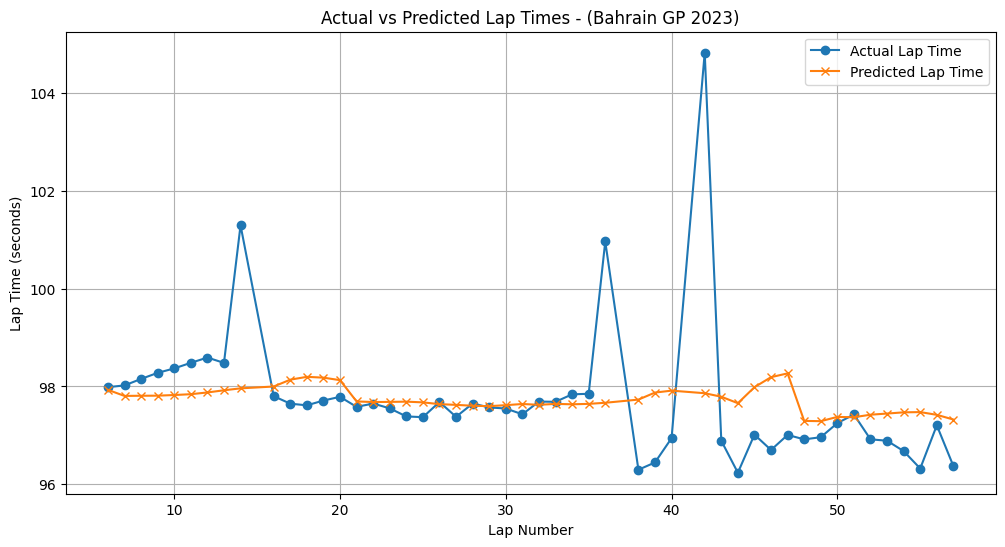

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(lap_numbers, y_true.flatten(), label='Actual Lap Time', marker='o')
plt.plot(lap_numbers, y_pred.flatten(), label='Predicted Lap Time', marker='x')

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Actual vs Predicted Lap Times - (Bahrain GP 2023)')
plt.legend()
plt.grid(True)
plt.show()


## **ERROR DETECTION**

In [ ]:
errors = y_true.flatten() - y_pred.flatten()
print("Mean Absolute Error (seconds):", abs(errors).mean())


Mean Absolute Error (seconds): 0.7384622030452811


## **TRACK VISUALIZATION**

In [ ]:

ver_laps_ff1 = session.laps.pick_driver('VER')


lap = ver_laps_ff1.pick_fastest()


telemetry = lap.get_telemetry()

telemetry.head()


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2023-03-05 16:14:59.563,0 days 02:13:57.714000,,NaN,0 days 00:00:00,11271.212513,284.412500,7,100.0,False,0,interpolation,0.010802,0.000002,OnTrack,-382.256646,1221.030661,-158.981903
3,2023-03-05 16:14:59.625,0 days 02:13:57.776000,,NaN,0 days 00:00:00.062000,11283.870820,284.670833,7,100.0,False,0,pos,4.920572,0.000915,OnTrack,-380.000000,1270.000000,-159.000000
4,2023-03-05 16:14:59.704,0 days 02:13:57.855000,,NaN,0 days 00:00:00.141000,11300.000000,285.000000,7,100.0,False,0,car,11.190000,0.002082,OnTrack,-377.234236,1332.493638,-159.036512
5,2023-03-05 16:14:59.825,0 days 02:13:57.976000,,NaN,0 days 00:00:00.262000,11338.460694,285.864285,7,100.0,False,0,pos,20.821555,0.003873,OnTrack,-373.000000,1429.000000,-159.000000
6,2023-03-05 16:14:59.984,0 days 02:13:58.135000,,NaN,0 days 00:00:00.421000,11389.000000,287.000000,7,100.0,False,0,car,33.512222,0.006234,OnTrack,-366.815026,1558.804999,-158.461578


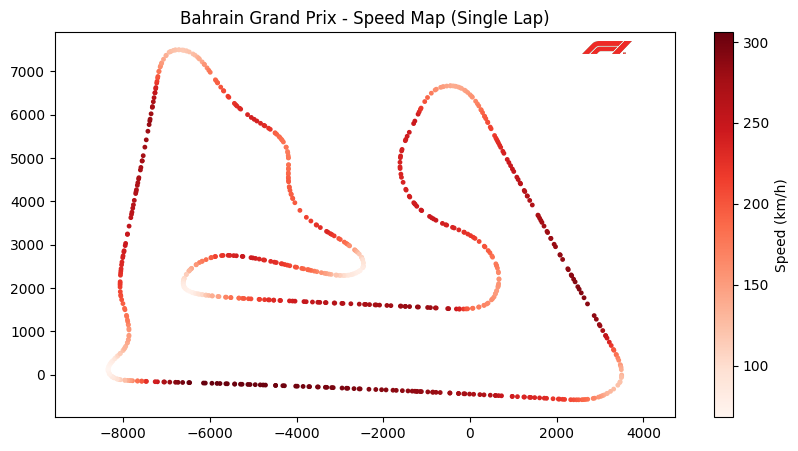

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(10, 5))

x_pov = -telemetry['Y']
y_pov = telemetry['X']

sc = plt.scatter( x_pov, y_pov, c=telemetry['Speed'], cmap='Reds', s=6 )

plt.colorbar(sc, label='Speed (km/h)')
plt.title('Bahrain Grand Prix - Speed Map (Single Lap)')
plt.axis('equal')
plt.axis('on')

logo = mpimg.imread('/content/logo.png')
ax = plt.gca()
logo_ax = ax.inset_axes([0.85, 0.90, 0.08, 0.12])

logo_ax.imshow(logo)
logo_ax.axis('off')

plt.show()


In [ ]:
--